# Transient & MCMC I

Let's study transient fenomena with the use of MCMC and Metropolis-Hastings algorithm.

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [106]:
data = np.load("../Solutions/transient.npy")
time, flux, error = data.T

In [ ]:
# Define the model
def Model(t, b, A, alpha, t0):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL 

# Define the log-prior
def logPrior(theta):
    b, A, alpha, t0 = theta
    if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
        return -np.log(alpha) 
    return -np.inf 

# Define the log-posterior
def logPosterior(theta, t, flux, error):
    logP = logPrior(theta)
    if not np.isfinite(logP):
        return -np.inf
    return logP + logLikelihood(theta, t, flux, error)

In [108]:
ndim = 4
nwalkers = 50

We need to take into account a thermalization time, plus the autocorralation. We run a smal test to set the burn and the thinning for the chain.

  2%|▏         | 31/2000 [00:00<00:06, 309.44it/s]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_17974/2480525843.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 2000/2000 [00:02<00:00, 871.41it/s]


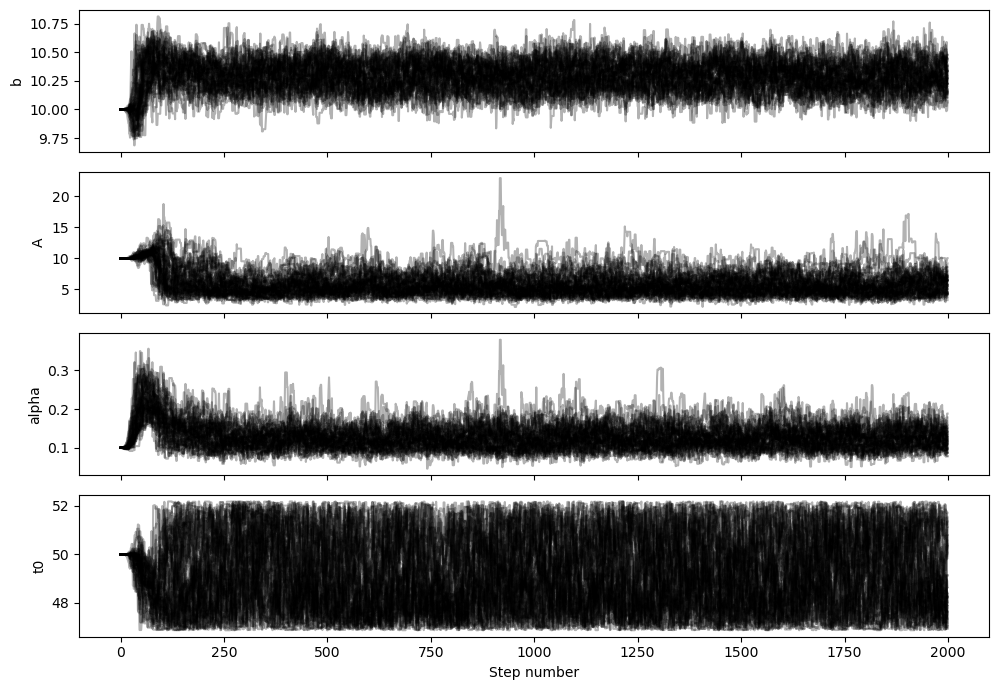

In [109]:
burn = 2000
try_sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))
initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)
try_sempler.run_mcmc(initial_pos, burn, progress=True)

traces = try_sempler.get_chain()
labels = ["b", "A", "alpha", "t0"]
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(traces[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()

Let's conclude that we need at least 100 steps to burn the chain.

In [110]:
tau = try_sempler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [39.7335695  71.20764975 55.683804   55.1709174 ]

In [111]:
# Run the sampler for a longer time to get better estimates, considering the autocorrelation time
burn = 500
nsteps = 10000

sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))

initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)

sempler.run_mcmc(initial_pos, nsteps, progress=True)

  0%|          | 0/10000 [00:00<?, ?it/s]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_17974/2480525843.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 10000/10000 [00:11<00:00, 900.77it/s]


State([[10.33875397  4.26267759  0.13577675 51.7049903 ]
 [10.4386855   3.72465593  0.12428834 51.53688669]
 [10.33607737  4.30490427  0.13622689 52.06024911]
 [10.08940598  5.53756045  0.10179965 48.68674278]
 [10.33927089  8.46372573  0.16104799 47.58066819]
 [10.17068364  6.00299253  0.11134316 49.97880218]
 [10.40610271  6.23986699  0.17715845 50.72831404]
 [10.28786052  6.00697214  0.16239746 50.03846945]
 [10.02778921 10.94582572  0.19187359 48.24897365]
 [10.34365448  4.80464537  0.14313146 49.97748262]
 [10.22307023  3.19488944  0.13117248 51.79796544]
 [10.36947268  8.93431731  0.15607365 47.21911773]
 [10.4330856   5.85430187  0.19940126 50.39676687]
 [10.28189583  6.82922692  0.13053125 48.0292475 ]
 [10.30371904  5.04231633  0.13349075 49.50712346]
 [10.21997791  4.91677653  0.12057018 50.7136216 ]
 [10.11359185  5.50055859  0.12756614 48.38695487]
 [10.2351944   6.08806152  0.15323478 50.26405641]
 [10.50771099  5.2154826   0.1895426  51.20335206]
 [10.24660483  7.8000326 

In [112]:
tau = sempler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)

[57.77327772 72.78105277 61.65067684 69.02640089]


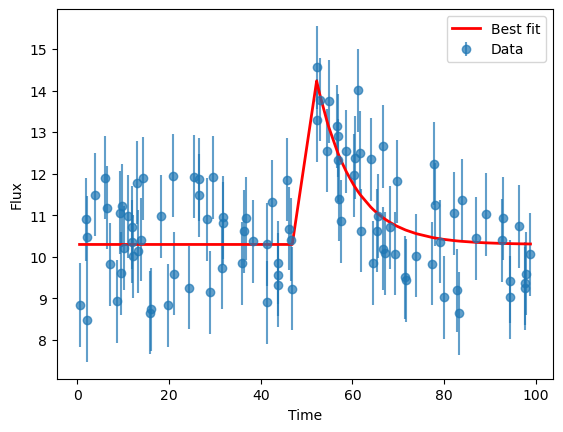

In [113]:
samples = sempler.get_chain(discard=burn, thin=thin, flat=True)

best_params = samples.mean(axis=0)

plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
model_flux = Model(time, *best_params)
plt.plot(time, model_flux, 'r-', label='Best fit', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

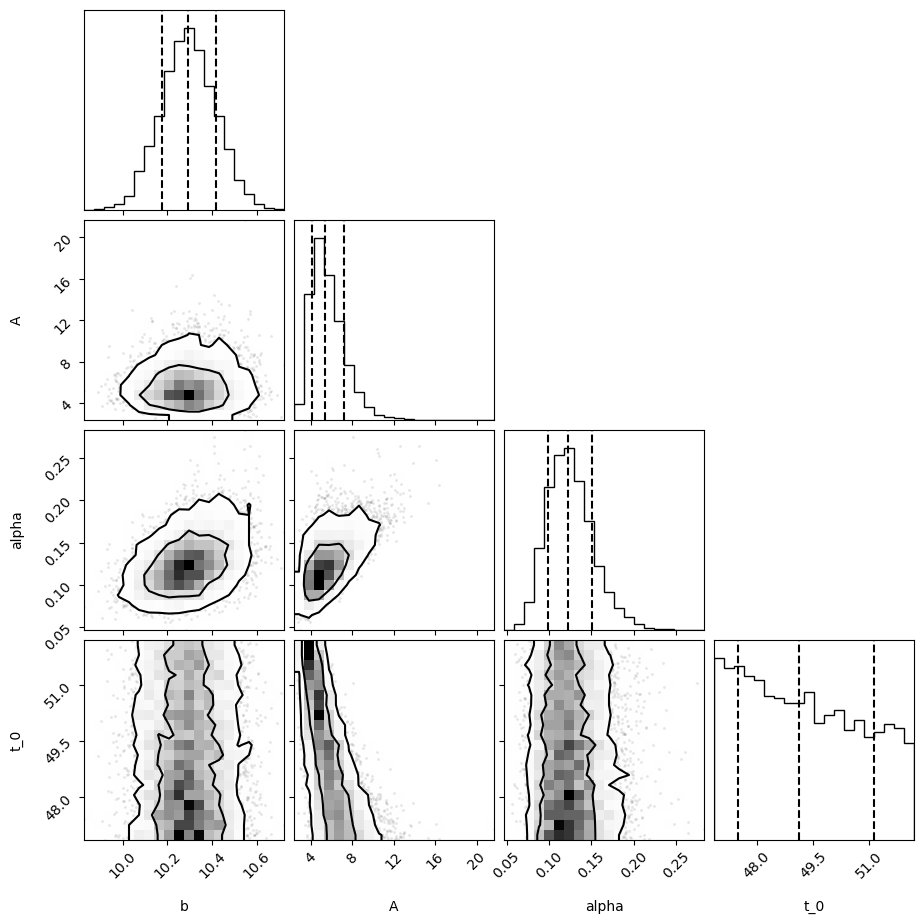

In [114]:
import corner as corner

labels = ["b", "A", "alpha", "t_0"]

fig = corner.corner(
    samples, 
    labels=labels, 
    levels=[0.68, 0.95],
    quantiles=[0.16, 0.5, 0.84]
)
plt.show()

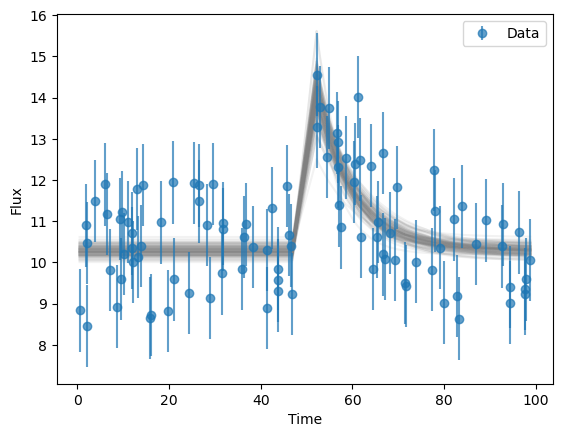

In [115]:
random_samples = samples[np.random.choice(samples.shape[0], size=100, replace=False)]

for i in range(len(random_samples)):
    y = Model(time, *random_samples[i])
    plt.plot(time, y, color='gray', alpha=0.1)
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()


In [116]:
median_params = np.median(samples, axis=0)
percentiles_params = np.percentile(samples, [5, 95], axis=0)

for i, param in enumerate(labels):
    print(f"{param}: {median_params[i]:.3f} (+{percentiles_params[1, i] - median_params[i]:.3f}, -{median_params[i] - percentiles_params[0, i]:.3f})")

b: 10.292 (+0.202, -0.199)
A: 5.383 (+3.323, -1.798)
alpha: 0.122 (+0.052, -0.037)
t_0: 49.131 (+2.686, -2.076)


We can check also the walker bheaviuor.

Mean acceptance fraction: 0.5318780000000001
Acceptance fraction (per walker, first 10): [0.5302 0.5299 0.5312 0.5283 0.5259 0.5293 0.5247 0.5281 0.5301 0.5241]


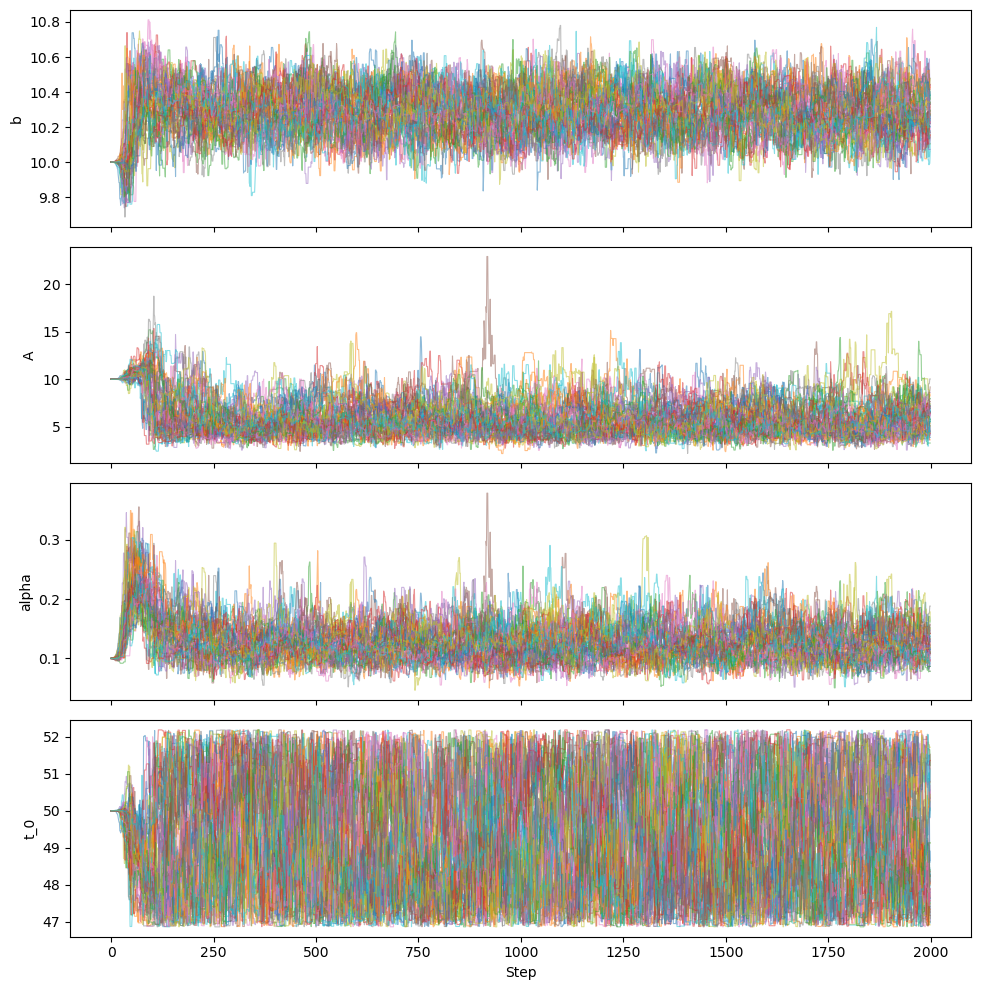

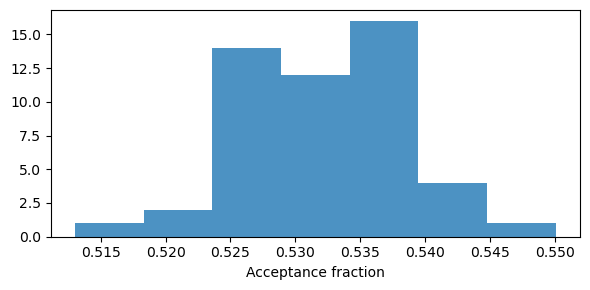

In [117]:
acc = getattr(sempler, "acceptance_fraction", None)
if acc is not None:
    print("Mean acceptance fraction:", acc.mean())
    print("Acceptance fraction (per walker, first 10):", acc[:10])

fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.5 * ndim), sharex=True)
for j in range(ndim):
    ax = axes[j]
    ax.plot(traces[:, :, j], lw=0.8, alpha=0.5)
    ax.set_ylabel(labels[j])
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

if acc is not None:
    plt.figure(figsize=(6,3))
    plt.hist(acc, bins='scott', alpha=0.8)
    plt.xlabel("Acceptance fraction")
    plt.tight_layout()
    plt.show()

### Savage-Dickey ratio

Use to check that indeed we have a signal over noise.

In [165]:
from sklearn.neighbors import KernelDensity

def kde(samples, bandwith, kernel):
    kde = KernelDensity(bandwidth=bandwith, kernel=kernel)
    kde.fit(samples[:, None])
    return kde

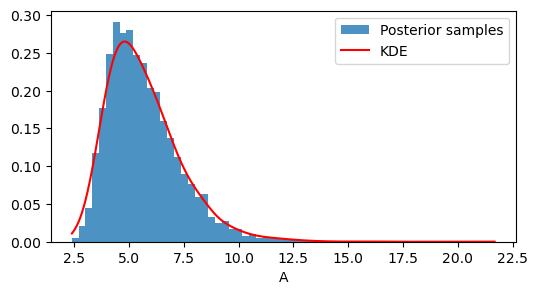

In [169]:
posterior_samples = samples[:, 1]
posterior_kde = kde(posterior_samples, bandwith=0.5, kernel='gaussian')

plt.figure(figsize=(6,3))
plt.hist(posterior_samples, bins='scott', density=True, alpha=0.8, label='Posterior samples')
x = np.linspace(posterior_samples.min(), posterior_samples.max(), 1000)[:, None]
log_dens = posterior_kde.score_samples(x)
plt.plot(x, np.exp(log_dens), 'r-', label='KDE')
plt.xlabel("A")
plt.legend()

In [170]:
A_ref = 0.0
posterior_density = np.exp(posterior_kde.score_samples([[A_ref]]))[0]
prior_density = 1 / 50
bayes_factor = prior_density / posterior_density

print(f'Posterior density at A={A_ref}: {posterior_density:.3e}')
print(f'Prior density at A={A_ref}: {prior_density:.3e}')
print(f'Approximate Savage-Dickey Bayes factor: {bayes_factor:.3f}')

Posterior density at A=0.0: 4.170e-09
Prior density at A=0.0: 2.000e-02
Approximate Savage-Dickey Bayes factor: 4796369.789


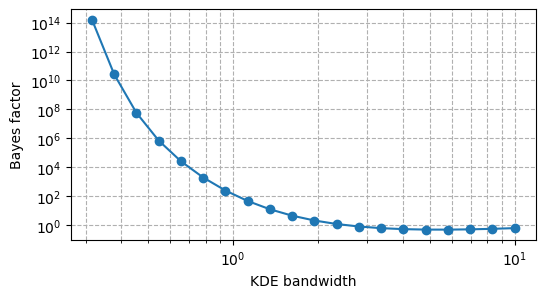

In [171]:
bandwith = np.logspace(-0.5, 1, 20)
bayesian_factors = []

for bw in bandwith:
    posterior_kde = kde(posterior_samples, bandwith=bw, kernel='gaussian')
    posterior_density = np.exp(posterior_kde.score_samples([[A_ref]]))[0]
    bayes_factor = prior_density / posterior_density
    bayesian_factors.append(bayes_factor)

plt.figure(figsize=(6,3))
plt.loglog(bandwith, bayesian_factors, marker='o')
plt.xlabel('KDE bandwidth')
plt.ylabel('Bayes factor')
plt.grid(True, which="both", ls="--")
plt.show()

We can confirm what we qualitatively expected: we have identified a clear signal over noise. However, we shouldn't put much confidence in the precise value of the Bayes factor for this claim, since it is sensitive to the KDE bandwidth choice in the tail region.